## This notebook will be using the physical coupling only model, and $\kappa$ = 300

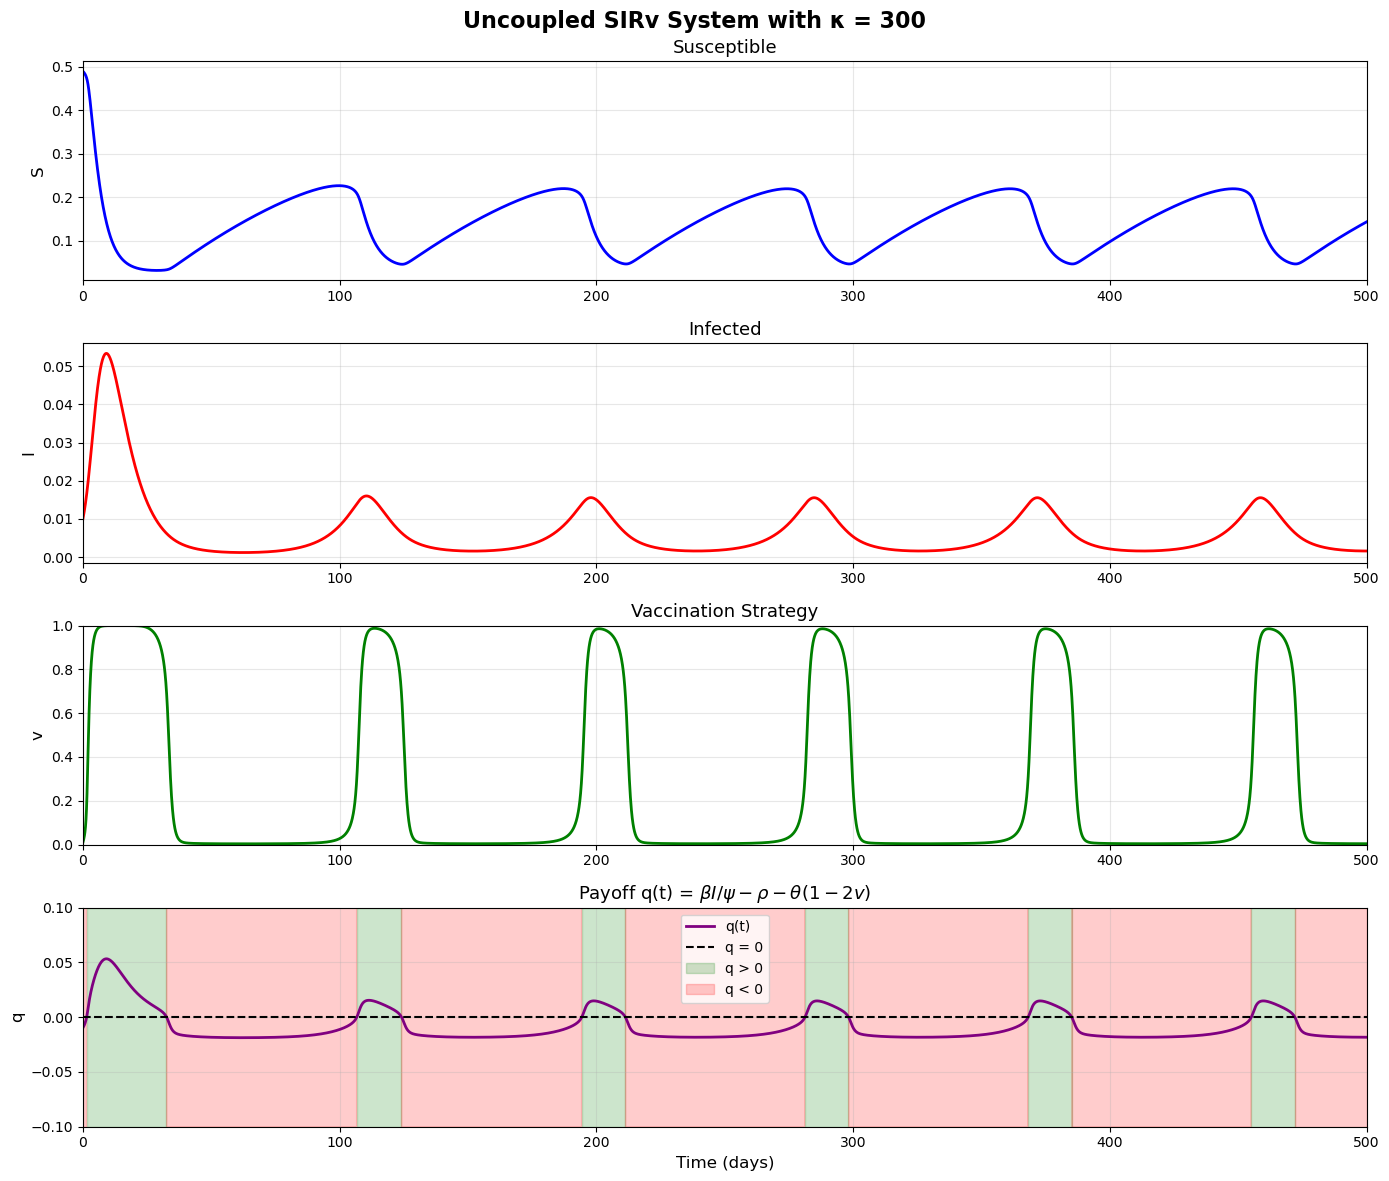

SIMULATION RESULTS (κ = 300)

Final values at t = 500.0 days:
S = 0.143599
I = 0.001622
v = 0.004122
q = -0.01829521

PAYOFF q STATISTICS
Mean q: -0.00852316
Min q: -0.01870915
Max q: 0.05330155
Std q: 0.01462116
Fraction of time q > 0: 0.2330
Fraction of time q < 0: 0.7670


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def uncoupled_smooth_sirv(t, y, alpha, beta, gamma, eta, theta, kappa, rho, psi):
    """
    Uncoupled smooth SIRv system (epsilon = 0)
    y = [S, I, v]
    """
    S, I, v = y
    
    dS = alpha*(psi - S - I) - beta*S*(I/psi) - eta*v*S
    dI = -gamma*I + beta*S*(I/psi)
    dv = -v + 1/(1 + np.exp(-kappa*(beta*I/psi - rho - theta*(1 - 2*v))))
    
    return [dS, dI, dv]

# Parameters
params = {
    'alpha': 0.01,
    'beta': 0.5,
    'gamma': 1/7,
    'eta': 1/7,
    'theta': 0.01,
    'kappa': 300,  # Changed from 1000 to 100
    'rho': 0.01,
    'psi': 0.5
}

# Initial conditions: [S0, I0, v0]
y0 = [0.49, 0.01, 0.01]

# Time span
t_span = (0, 500)
t_eval = np.linspace(t_span[0], t_span[1], 5000)

# Solve the system
sol = solve_ivp(
    uncoupled_smooth_sirv,
    t_span,
    y0,
    args=(params['alpha'], params['beta'], params['gamma'], params['eta'],
          params['theta'], params['kappa'], params['rho'], params['psi']),
    t_eval=t_eval,
    method='LSODA',
    rtol=1e-8,
    atol=1e-10
)

S, I, v = sol.y

# Calculate payoff q(t)
q_t = params['beta']*(I/params['psi']) - params['rho'] - params['theta']*(1 - 2*v)

# Create plots
fig, axes = plt.subplots(4, 1, figsize=(14, 12))
fig.suptitle(r'Uncoupled SIRv System with κ = 300', fontsize=16, fontweight='bold')

# Plot S
axes[0].plot(sol.t, S, 'b-', linewidth=2)
axes[0].set_ylabel('S', fontsize=12)
axes[0].set_title('Susceptible', fontsize=13)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 500)

# Plot I
axes[1].plot(sol.t, I, 'r-', linewidth=2)
axes[1].set_ylabel('I', fontsize=12)
axes[1].set_title('Infected', fontsize=13)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, 500)

# Plot v
axes[2].plot(sol.t, v, 'g-', linewidth=2)
axes[2].set_ylabel('v', fontsize=12)
axes[2].set_title('Vaccination Strategy', fontsize=13)
axes[2].set_ylim([0, 1])
axes[2].grid(True, alpha=0.3)
axes[2].set_xlim(0, 500)

# Plot q(t)
axes[3].plot(sol.t, q_t, 'purple', linewidth=2, label='q(t)')
axes[3].axhline(y=0, color='k', linestyle='--', linewidth=1.5, label='q = 0')
axes[3].fill_between(sol.t, -0.1, 0.1, where=(q_t >= 0), 
                     alpha=0.2, color='green', label='q > 0')
axes[3].fill_between(sol.t, -0.1, 0.1, where=(q_t < 0), 
                     alpha=0.2, color='red', label='q < 0')
axes[3].set_ylabel('q', fontsize=12)
axes[3].set_xlabel('Time (days)', fontsize=12)
axes[3].set_title(r'Payoff q(t) = $\beta I/\psi - \rho - \theta(1-2v)$', fontsize=13)
axes[3].set_ylim(-0.1, 0.1)
axes[3].set_xlim(0, 500)
axes[3].legend(fontsize=10, loc='best')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("="*80)
print(f"SIMULATION RESULTS (κ = {params['kappa']})")
print("="*80)
print(f"\nFinal values at t = {sol.t[-1]:.1f} days:")
print(f"S = {S[-1]:.6f}")
print(f"I = {I[-1]:.6f}")
print(f"v = {v[-1]:.6f}")
print(f"q = {q_t[-1]:.8f}")

print("\n" + "="*80)
print("PAYOFF q STATISTICS")
print("="*80)
print(f"Mean q: {np.mean(q_t):.8f}")
print(f"Min q: {np.min(q_t):.8f}")
print(f"Max q: {np.max(q_t):.8f}")
print(f"Std q: {np.std(q_t):.8f}")
print(f"Fraction of time q > 0: {np.sum(q_t > 0) / len(q_t):.4f}")
print(f"Fraction of time q < 0: {np.sum(q_t < 0) / len(q_t):.4f}")

## Do they synchronize

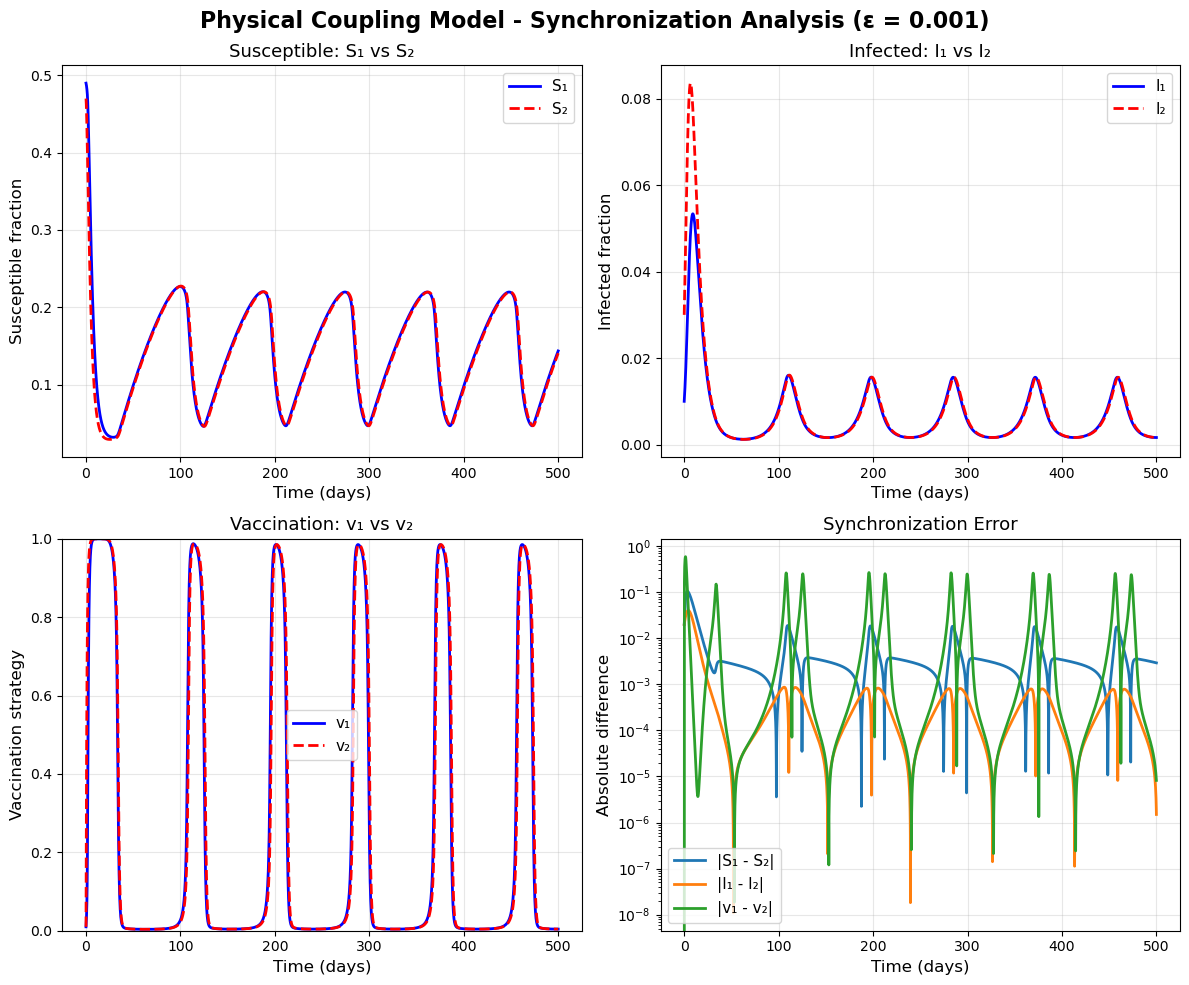


Synchronization Analysis at t = 500.0 days:
Final |S₁ - S₂| = 0.002923
Final |I₁ - I₂| = 0.000001
Final |v₁ - v₂| = 0.000008

Mean absolute differences over time:
Mean |S₁ - S₂| = 0.005452
Mean |I₁ - I₂| = 0.001122
Mean |v₁ - v₂| = 0.021953


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Define the coupled system
def coupled_sirv(t, y, alpha, beta, gamma, epsilon, eta, theta, kappa, rho, psi):
    """
    Coupled SIRv system with physical coupling (infection across groups)
    y = [S1, I1, v1, S2, I2, v2]
    """
    S1, I1, v1, S2, I2, v2 = y
    
    # Effective infection rates seen by each group
    infection_rate_1 = (1 - epsilon) * I1 / psi + epsilon * I2 / (1 - psi)
    infection_rate_2 = (1 - epsilon) * I2 / (1 - psi) + epsilon * I1 / psi
    
    # Group 1 dynamics
    dS1 = alpha*(psi - S1 - I1) - beta*S1*infection_rate_1 - eta*v1*S1
    dI1 = -gamma*I1 + beta*S1*infection_rate_1
    dv1 = -v1 + 1/(1 + np.exp(-kappa*(beta*infection_rate_1 - rho - theta*(1 - 2*v1))))
    
    # Group 2 dynamics
    dS2 = alpha*(1 - psi - S2 - I2) - beta*S2*infection_rate_2 - eta*v2*S2
    dI2 = -gamma*I2 + beta*S2*infection_rate_2
    dv2 = -v2 + 1/(1 + np.exp(-kappa*(beta*infection_rate_2 - rho - theta*(1 - 2*v2))))
    
    return [dS1, dI1, dv1, dS2, dI2, dv2]

# Default parameters
params = {
    'alpha': 0.01,
    'beta': 0.5,
    'gamma': 1/7,
    'epsilon': 0.001,
    'eta': 1/7,
    'theta': 0.01,
    'kappa': 300,
    'rho': 0.01,
    'psi': 0.5
}

# Initial conditions: (S1, I1, v1, S2, I2, v2)
y0 = [0.49, 0.01, 0.01, 0.47, 0.03, 0.01]

# Time span
t_span = (0, 500)
t_eval = np.linspace(t_span[0], t_span[1], 5000)

# Solve the system
sol = solve_ivp(
    coupled_sirv, 
    t_span, 
    y0, 
    args=(params['alpha'], params['beta'], params['gamma'], params['epsilon'], 
          params['eta'], params['theta'], params['kappa'], params['rho'], params['psi']),
    t_eval=t_eval,
    method='LSODA',
    rtol=1e-8,
    atol=1e-10
)

# Extract solutions
S1, I1, v1, S2, I2, v2 = sol.y

# Create synchronization comparison plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(f'Physical Coupling Model - Synchronization Analysis (ε = {params["epsilon"]})', fontsize=16, fontweight='bold')

# S1 vs S2
axes[0, 0].plot(sol.t, S1, 'b-', label='S₁', linewidth=2)
axes[0, 0].plot(sol.t, S2, 'r--', label='S₂', linewidth=2)
axes[0, 0].set_xlabel('Time (days)', fontsize=12)
axes[0, 0].set_ylabel('Susceptible fraction', fontsize=12)
axes[0, 0].set_title('Susceptible: S₁ vs S₂', fontsize=13)
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# I1 vs I2
axes[0, 1].plot(sol.t, I1, 'b-', label='I₁', linewidth=2)
axes[0, 1].plot(sol.t, I2, 'r--', label='I₂', linewidth=2)
axes[0, 1].set_xlabel('Time (days)', fontsize=12)
axes[0, 1].set_ylabel('Infected fraction', fontsize=12)
axes[0, 1].set_title('Infected: I₁ vs I₂', fontsize=13)
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(True, alpha=0.3)

# v1 vs v2
axes[1, 0].plot(sol.t, v1, 'b-', label='v₁', linewidth=2)
axes[1, 0].plot(sol.t, v2, 'r--', label='v₂', linewidth=2)
axes[1, 0].set_xlabel('Time (days)', fontsize=12)
axes[1, 0].set_ylabel('Vaccination strategy', fontsize=12)
axes[1, 0].set_title('Vaccination: v₁ vs v₂', fontsize=13)
axes[1, 0].legend(fontsize=11)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim([0, 1])

# Difference measures
axes[1, 1].plot(sol.t, np.abs(S1 - S2), label='|S₁ - S₂|', linewidth=2)
axes[1, 1].plot(sol.t, np.abs(I1 - I2), label='|I₁ - I₂|', linewidth=2)
axes[1, 1].plot(sol.t, np.abs(v1 - v2), label='|v₁ - v₂|', linewidth=2)
axes[1, 1].set_xlabel('Time (days)', fontsize=12)
axes[1, 1].set_ylabel('Absolute difference', fontsize=12)
axes[1, 1].set_title('Synchronization Error', fontsize=13)
axes[1, 1].legend(fontsize=11)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_yscale('log')

plt.tight_layout()
plt.show()

# Print synchronization metrics
print(f"\nSynchronization Analysis at t = {sol.t[-1]:.1f} days:")
print(f"Final |S₁ - S₂| = {abs(S1[-1] - S2[-1]):.6f}")
print(f"Final |I₁ - I₂| = {abs(I1[-1] - I2[-1]):.6f}")
print(f"Final |v₁ - v₂| = {abs(v1[-1] - v2[-1]):.6f}")
print(f"\nMean absolute differences over time:")
print(f"Mean |S₁ - S₂| = {np.mean(np.abs(S1 - S2)):.6f}")
print(f"Mean |I₁ - I₂| = {np.mean(np.abs(I1 - I2)):.6f}")
print(f"Mean |v₁ - v₂| = {np.mean(np.abs(v1 - v2)):.6f}")

## yes the coupled system synchronizes
## Now do the adjoint methods. First, get limit cycle $\Gamma(t)$. It is the same from the social only system since $\Gamma$ and in fact Z(t) are all derived from just the uncoupled system.

State after transients: S=0.074184, I=0.003062, v=0.007353
Period T = 86.910000 days
Closure error: 1.63e-05

LIMIT CYCLE FOUND
Period T = 86.910000 days
Number of points: 10000

Starting point γ(0):
  S(0) = 0.14279999
  I(0) = 0.01556178
  v(0) = 0.94464251

Variable ranges:
  S ∈ [0.046628, 0.219686]
  I ∈ [0.001622, 0.015562]
  v ∈ [0.004120, 0.985381]


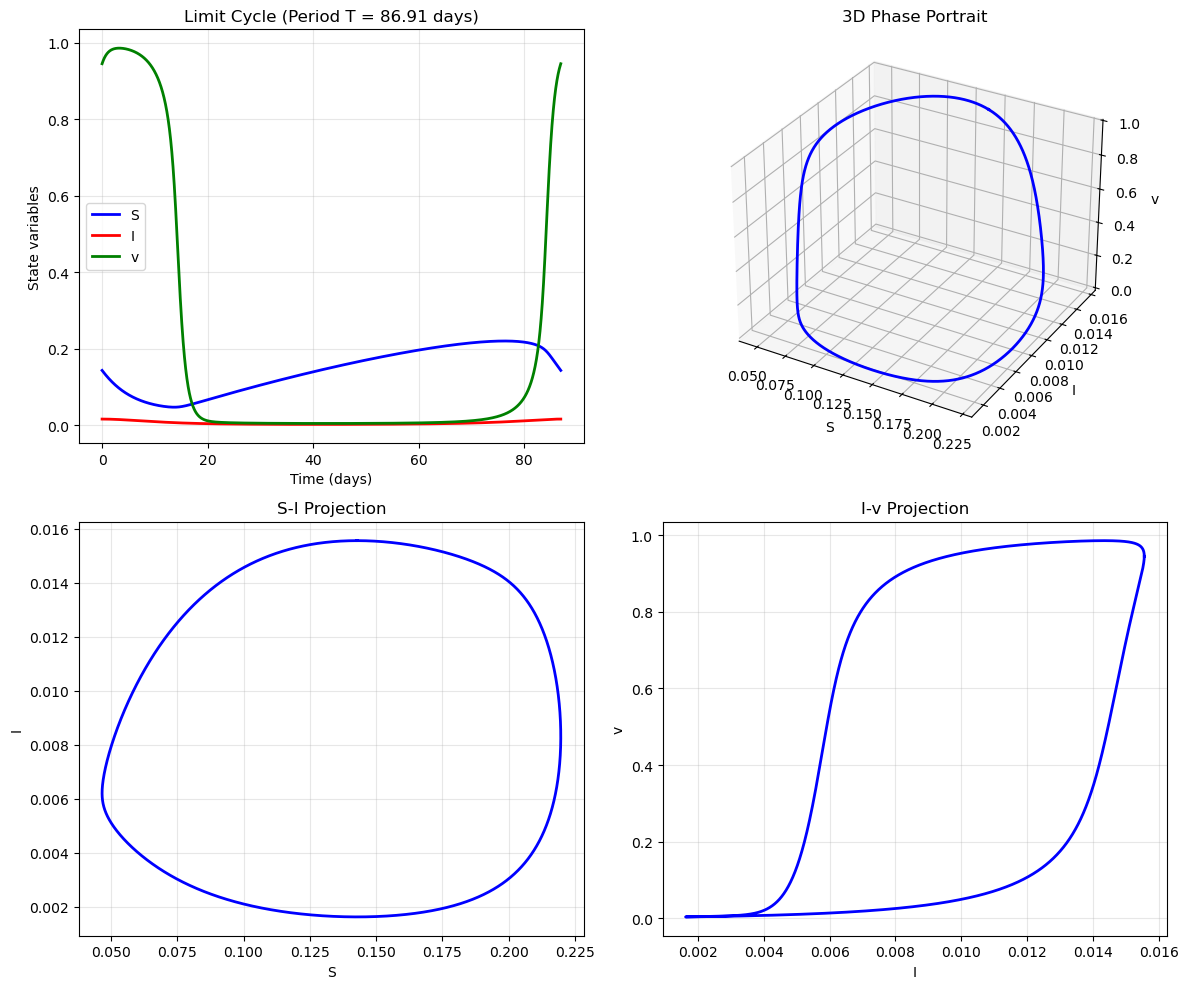

In [1]:
"""
Find the limit cycle (periodic orbit) for the uncoupled smooth SIRv system.

This script:
1. Integrates the system for a long time to reach the attractor
2. Detects the period using Poincaré section crossings
3. Extracts one complete cycle γ(t) = [S(t), I(t), v(t)]
4. Verifies periodicity
"""

import numpy as np
from scipy.integrate import solve_ivp
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt


# =============================================================================
# SYSTEM DEFINITION
# =============================================================================

def uncoupled_smooth_sirv(t, y, params):
    """
    Uncoupled smooth SIRv system (epsilon = 0)
    y = [S, I, v]
    """
    S, I, v = y
    alpha = params['alpha']
    beta = params['beta']
    gamma = params['gamma']
    eta = params['eta']
    theta = params['theta']
    kappa = params['kappa']
    rho = params['rho']
    psi = params['psi']
    
    dS = alpha*(psi - S - I) - beta*S*(I/psi) - eta*v*S
    dI = -gamma*I + beta*S*(I/psi)
    dv = -v + 1/(1 + np.exp(-kappa*(beta*I/psi - rho - theta*(1 - 2*v))))
    
    return [dS, dI, dv]


# =============================================================================
# PARAMETERS
# =============================================================================

params = {
    'alpha': 0.01,
    'beta': 0.5,
    'gamma': 1/7,
    'eta': 1/7,
    'theta': 0.01,
    'kappa': 300,
    'rho': 0.01,
    'psi': 0.5
}

y0 = [0.49, 0.01, 0.01]  # Initial conditions [S0, I0, v0]


# =============================================================================
# STEP 1: INTEGRATE PAST TRANSIENTS
# =============================================================================

t_transient = 5000

sol_transient = solve_ivp(
    lambda t, y: uncoupled_smooth_sirv(t, y, params),
    [0, t_transient],
    y0,
    method='RK45',
    rtol=1e-10,
    atol=1e-12
)

y_after_transient = sol_transient.y[:, -1]
print(f"State after transients: S={y_after_transient[0]:.6f}, "
      f"I={y_after_transient[1]:.6f}, v={y_after_transient[2]:.6f}")


# =============================================================================
# STEP 2: FIND THE PERIOD
# =============================================================================

t_cycle_search = 2000
dt = 0.01
t_eval = np.arange(0, t_cycle_search, dt)

sol_search = solve_ivp(
    lambda t, y: uncoupled_smooth_sirv(t, y, params),
    [0, t_cycle_search],
    y_after_transient,
    method='RK45',
    t_eval=t_eval,
    rtol=1e-10,
    atol=1e-12
)

# Find peaks in I to determine period
I_data = sol_search.y[1, :]
peaks, _ = find_peaks(I_data, height=np.mean(I_data), distance=int(1/dt))

peak_times = sol_search.t[peaks]
periods = np.diff(peak_times)
T = np.mean(periods[-5:])  # Average of last 5 periods

print(f"Period T = {T:.6f} days")


# =============================================================================
# STEP 3: EXTRACT ONE COMPLETE CYCLE
# =============================================================================

# Start from a peak (phase = 0 at peak I)
start_idx = peaks[-2]
y_cycle_start = sol_search.y[:, start_idx]

# Integrate for exactly one period
n_points = 10000
t_cycle = np.linspace(0, T, n_points)

sol_cycle = solve_ivp(
    lambda t, y: uncoupled_smooth_sirv(t, y, params),
    [0, T],
    y_cycle_start,
    method='RK45',
    t_eval=t_cycle,
    rtol=1e-12,
    atol=1e-14
)


# =============================================================================
# STEP 4: STORE THE LIMIT CYCLE AS Gamma
# =============================================================================

class Gamma:
    """
    Container for the limit cycle γ(t) = [S(t), I(t), v(t)]
    
    Usage:
        Gamma.t    - time array [0, T]
        Gamma.S    - S(t) along the cycle
        Gamma.I    - I(t) along the cycle
        Gamma.v    - v(t) along the cycle
        Gamma.T    - period
        Gamma.y    - full state array, shape (3, n_points)
    """
    t = sol_cycle.t
    S = sol_cycle.y[0, :]
    I = sol_cycle.y[1, :]
    v = sol_cycle.y[2, :]
    T = T
    y = sol_cycle.y  # [S, I, v] stacked


# =============================================================================
# STEP 5: VERIFY PERIODICITY
# =============================================================================

closure_error = np.linalg.norm(Gamma.y[:, -1] - Gamma.y[:, 0])
print(f"Closure error: {closure_error:.2e}")


# =============================================================================
# PRINT SUMMARY
# =============================================================================

print("\n" + "="*50)
print("LIMIT CYCLE FOUND")
print("="*50)
print(f"Period T = {Gamma.T:.6f} days")
print(f"Number of points: {len(Gamma.t)}")
print(f"\nStarting point γ(0):")
print(f"  S(0) = {Gamma.S[0]:.8f}")
print(f"  I(0) = {Gamma.I[0]:.8f}")
print(f"  v(0) = {Gamma.v[0]:.8f}")
print(f"\nVariable ranges:")
print(f"  S ∈ [{Gamma.S.min():.6f}, {Gamma.S.max():.6f}]")
print(f"  I ∈ [{Gamma.I.min():.6f}, {Gamma.I.max():.6f}]")
print(f"  v ∈ [{Gamma.v.min():.6f}, {Gamma.v.max():.6f}]")


# =============================================================================
# PLOT
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Time series
ax1 = axes[0, 0]
ax1.plot(Gamma.t, Gamma.S, 'b-', label='S', linewidth=2)
ax1.plot(Gamma.t, Gamma.I, 'r-', label='I', linewidth=2)
ax1.plot(Gamma.t, Gamma.v, 'g-', label='v', linewidth=2)
ax1.set_xlabel('Time (days)')
ax1.set_ylabel('State variables')
ax1.set_title(f'Limit Cycle (Period T = {Gamma.T:.2f} days)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 3D phase portrait
ax2 = fig.add_subplot(2, 2, 2, projection='3d')
ax2.plot(Gamma.S, Gamma.I, Gamma.v, 'b-', linewidth=2)
ax2.set_xlabel('S')
ax2.set_ylabel('I')
ax2.set_zlabel('v')
ax2.set_title('3D Phase Portrait')
axes[0, 1].remove()

# S-I projection
ax3 = axes[1, 0]
ax3.plot(Gamma.S, Gamma.I, 'b-', linewidth=2)
ax3.set_xlabel('S')
ax3.set_ylabel('I')
ax3.set_title('S-I Projection')
ax3.grid(True, alpha=0.3)

# I-v projection
ax4 = axes[1, 1]
ax4.plot(Gamma.I, Gamma.v, 'b-', linewidth=2)
ax4.set_xlabel('I')
ax4.set_ylabel('v')
ax4.set_title('I-v Projection')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('limit_cycle_plot.png', dpi=150)
plt.show()

## Now use SYMPY to calculate DF, to get A = DF(Gamma(t))

In [3]:
# =============================================================================
# COMPUTE THE JACOBIAN DF USING SYMPY
# =============================================================================

import sympy as sp

# Define symbolic variables
S_sym, I_sym, v_sym = sp.symbols('S I v')
alpha_sym, beta_sym, gamma_sym, eta_sym = sp.symbols('alpha beta gamma eta')
theta_sym, kappa_sym, rho_sym, psi_sym = sp.symbols('theta kappa rho psi')

# Define the vector field F = [F1, F2, F3]
F1 = alpha_sym*(psi_sym - S_sym - I_sym) - beta_sym*S_sym*(I_sym/psi_sym) - eta_sym*v_sym*S_sym
F2 = -gamma_sym*I_sym + beta_sym*S_sym*(I_sym/psi_sym)
F3 = -v_sym + 1/(1 + sp.exp(-kappa_sym*(beta_sym*I_sym/psi_sym - rho_sym - theta_sym*(1 - 2*v_sym))))

F = sp.Matrix([F1, F2, F3])
state = sp.Matrix([S_sym, I_sym, v_sym])

# Compute Jacobian symbolically
DF_symbolic = F.jacobian(state)

print("Symbolic Jacobian DF:")
print("="*50)
sp.pprint(DF_symbolic)

# Convert to numerical function
param_symbols = (alpha_sym, beta_sym, gamma_sym, eta_sym, theta_sym, kappa_sym, rho_sym, psi_sym)
all_symbols = (S_sym, I_sym, v_sym) + param_symbols

DF_func = sp.lambdify(all_symbols, DF_symbolic, modules='numpy')


def compute_DF(S, I, v, params):
    """
    Compute the Jacobian matrix DF at a point (S, I, v).
    
    Returns:
        DF : 3x3 numpy array
    """
    return np.array(DF_func(
        S, I, v,
        params['alpha'], params['beta'], params['gamma'], params['eta'],
        params['theta'], params['kappa'], params['rho'], params['psi']
    ))

Symbolic Jacobian DF:
⎡  I⋅β                           S⋅β                                           ↪
⎢- ─── - α - η⋅v               - ─── - α                                 -S⋅η  ↪
⎢   ψ                             ψ                                            ↪
⎢                                                                              ↪
⎢      I⋅β                      S⋅β                                            ↪
⎢      ───                      ─── - γ                                   0    ↪
⎢       ψ                        ψ                                             ↪
⎢                                                                              ↪
⎢                           ⎛I⋅β                  ⎞               ⎛I⋅β         ↪
⎢                        -κ⋅⎜─── - ρ - θ⋅(1 - 2⋅v)⎟            -κ⋅⎜─── - ρ - θ ↪
⎢                           ⎝ ψ                   ⎠               ⎝ ψ          ↪
⎢                   β⋅κ⋅ℯ                               2⋅κ⋅θ⋅ℯ                ↪
⎢     

## Now compute A(t)

In [5]:
# =============================================================================
# COMPUTE A(t) = DF(Gamma(t)) ALONG THE LIMIT CYCLE
# =============================================================================

n_points = len(Gamma.t)
A = np.zeros((n_points, 3, 3))

for i in range(n_points):
    A[i] = compute_DF(Gamma.S[i], Gamma.I[i], Gamma.v[i], params)

print(f"\nA(t) computed at {n_points} points along the limit cycle")
print(f"A has shape: {A.shape}")
print(f"\nExample: A(0) =")
print(A[0])


A(t) computed at 10000 points along the limit cycle
A has shape: (10000, 3, 3)

Example: A(0) =
[[-1.60510710e-01 -1.52799994e-01 -2.03999991e-02]
 [ 1.55617798e-02 -5.71490970e-05  0.00000000e+00]
 [ 0.00000000e+00  3.82437790e+00 -9.23512442e-01]]


## Backward integrate to get Z(t)

Computed γ'(t) = F(γ(t)) along the limit cycle
Backward integration over 7 periods complete
Total integration time: 608.37 days
Z_raw shape: (3, 10000)

PERIODICITY CHECK (before normalization)
Z_S(T) - Z_S(0) = -2.027381e-03
Z_I(T) - Z_I(0) = -5.509809e-04
Z_v(T) - Z_v(0) = 6.564309e-05
||Z(T) - Z(0)|| = 2.101942e-03

Period T = 86.910000
Angular frequency ω = 2π/T = 0.072295

Before normalization:
  Z · γ' ranges from 2.436619e-02 to 2.461363e-02

After normalization:
  Z · γ' should equal 2π/T = 0.072295
  Z · γ' ranges from 0.072295 to 0.072295

PERIODICITY CHECK (after normalization)
Z_S(T) - Z_S(0) = -4.940228e-05
Z_I(T) - Z_I(0) = 1.354870e-01
Z_v(T) - Z_v(0) = 1.054306e-04
||Z(T) - Z(0)|| = 1.354871e-01

Z(t) stored in Z container

ADJOINT SOLUTION Z(t) COMPUTED

Z(0) = [-3.859576, -88.846061, 0.057689]
Z(T) = [-3.859625, -88.710574, 0.057795]

Variable ranges:
  Z_S ∈ [-6.707581, 29.182637]
  Z_I ∈ [-126.756682, 455.366528]
  Z_v ∈ [-1.241970, 0.972882]


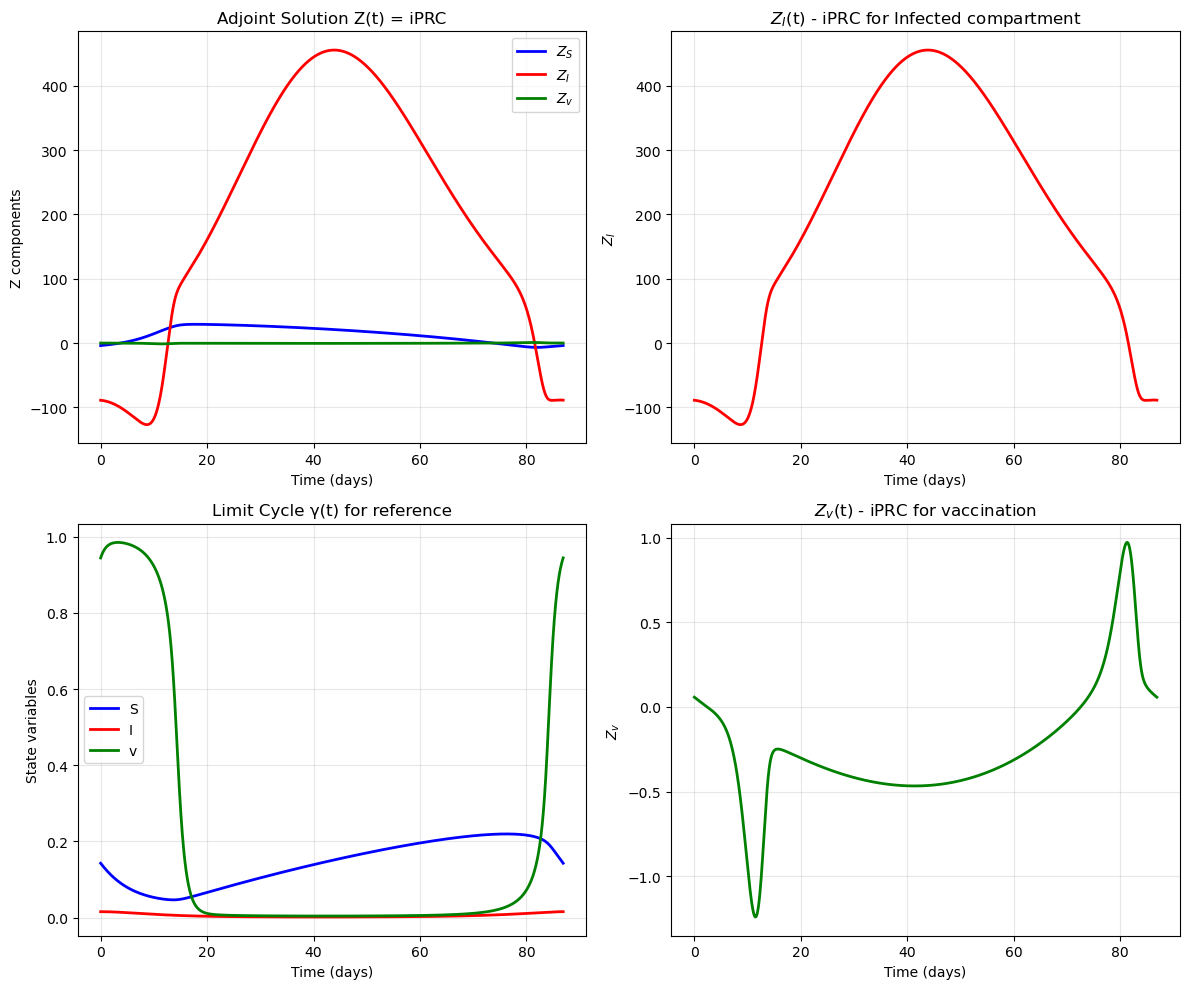

In [7]:
# =============================================================================
# COMPUTE Z(t) BY BACKWARD INTEGRATION OF THE ADJOINT EQUATION
# =============================================================================

from scipy.interpolate import interp1d

# -----------------------------------------------------------------------------
# Step 1: Compute γ'(t) = F(γ(t)) along the limit cycle
# -----------------------------------------------------------------------------

# γ'(t) is just the vector field evaluated along the cycle
Gamma_dot = np.zeros((3, n_points))
for i in range(n_points):
    Gamma_dot[:, i] = uncoupled_smooth_sirv(Gamma.t[i], Gamma.y[:, i], params)

# Store in Gamma for convenience
Gamma.S_dot = Gamma_dot[0, :]
Gamma.I_dot = Gamma_dot[1, :]
Gamma.v_dot = Gamma_dot[2, :]
Gamma.y_dot = Gamma_dot

print("Computed γ'(t) = F(γ(t)) along the limit cycle")


# -----------------------------------------------------------------------------
# Step 2: Create interpolation functions for A(t) - PERIODIC EXTENSION
# -----------------------------------------------------------------------------

def make_A_periodic_interp(t, A, T):
    """
    Create interpolation function for A(t) with periodic extension.
    A has shape (n_points, 3, 3)
    """
    def A_periodic(t_query):
        t_mod = np.mod(t_query, T)
        # Find the two nearest time points for interpolation
        idx = np.searchsorted(t, t_mod, side='right') - 1
        idx = np.clip(idx, 0, len(t) - 2)
        
        # Linear interpolation
        t0, t1 = t[idx], t[idx + 1]
        weight = (t_mod - t0) / (t1 - t0)
        return (1 - weight) * A[idx] + weight * A[idx + 1]
    
    return A_periodic

A_interp = make_A_periodic_interp(Gamma.t, A, Gamma.T)


# -----------------------------------------------------------------------------
# Step 3: Define the adjoint equation dZ/dt = -A(t)^T @ Z
# -----------------------------------------------------------------------------

def adjoint_equation_reversed(s, Z, A_interp, T):
    """
    Time-reversed adjoint equation for forward integration.
    
    s = T - t, so t = T - s
    dZ/ds = A(T-s)^T @ Z
    
    This lets us use a standard forward integrator.
    """
    t = T - s
    A_t = A_interp(t)
    return A_t.T @ Z


# -----------------------------------------------------------------------------
# Step 4: Backward integration over MULTIPLE PERIODS
# -----------------------------------------------------------------------------

n_periods = 7  # Integrate over 7 periods to ensure convergence to periodic solution
T_total = n_periods * Gamma.T

# Initial condition: random vector (will be normalized later)
Z_initial = np.array([1.0, 1.0, 1.0])

# Integrate over n_periods
n_points_total = n_points * n_periods
s_eval = np.linspace(0, T_total, n_points_total)

sol_adjoint = solve_ivp(
    lambda s, Z: adjoint_equation_reversed(s, Z, A_interp, Gamma.T),
    [0, T_total],
    Z_initial,
    method='RK45',
    t_eval=s_eval,
    rtol=1e-10,
    atol=1e-12
)

print(f"Backward integration over {n_periods} periods complete")
print(f"Total integration time: {T_total:.2f} days")

# Extract only the LAST period (which should be converged to the periodic solution)
# s goes from 0 to T_total, and we want the last period: s ∈ [(n_periods-1)*T, n_periods*T]
# After flipping, this corresponds to t ∈ [0, T]

# The solution at s corresponds to t = T_total - s (in the multi-period sense)
# We want the last period, so take the last n_points worth of data
Z_last_period = sol_adjoint.y[:, -n_points:]

# Flip to get Z(t) with t from 0 to T
Z_raw = Z_last_period[:, ::-1]

print(f"Z_raw shape: {Z_raw.shape}")


# -----------------------------------------------------------------------------
# Step 5: Verify periodicity BEFORE normalization
# -----------------------------------------------------------------------------

print("\n" + "="*50)
print("PERIODICITY CHECK (before normalization)")
print("="*50)
print(f"Z_S(T) - Z_S(0) = {Z_raw[0, -1] - Z_raw[0, 0]:.6e}")
print(f"Z_I(T) - Z_I(0) = {Z_raw[1, -1] - Z_raw[1, 0]:.6e}")
print(f"Z_v(T) - Z_v(0) = {Z_raw[2, -1] - Z_raw[2, 0]:.6e}")
print(f"||Z(T) - Z(0)|| = {np.linalg.norm(Z_raw[:, -1] - Z_raw[:, 0]):.6e}")


# -----------------------------------------------------------------------------
# Step 6: Normalize so that Z(t) · γ'(t) = 2π/T
# -----------------------------------------------------------------------------

omega = 2 * np.pi / Gamma.T  # angular frequency

# Compute Z · γ' at each point
Z_dot_Gamma_dot = np.sum(Z_raw * Gamma_dot, axis=0)

print(f"\nPeriod T = {Gamma.T:.6f}")
print(f"Angular frequency ω = 2π/T = {omega:.6f}")

print(f"\nBefore normalization:")
print(f"  Z · γ' ranges from {Z_dot_Gamma_dot.min():.6e} to {Z_dot_Gamma_dot.max():.6e}")

# Normalize: scale Z so that Z · γ' = 2π/T
Z_normalized = Z_raw * omega / Z_dot_Gamma_dot

# Verify normalization
Z_dot_Gamma_dot_check = np.sum(Z_normalized * Gamma_dot, axis=0)
print(f"\nAfter normalization:")
print(f"  Z · γ' should equal 2π/T = {omega:.6f}")
print(f"  Z · γ' ranges from {Z_dot_Gamma_dot_check.min():.6f} to {Z_dot_Gamma_dot_check.max():.6f}")


# -----------------------------------------------------------------------------
# Step 7: Verify periodicity AFTER normalization
# -----------------------------------------------------------------------------

print("\n" + "="*50)
print("PERIODICITY CHECK (after normalization)")
print("="*50)
print(f"Z_S(T) - Z_S(0) = {Z_normalized[0, -1] - Z_normalized[0, 0]:.6e}")
print(f"Z_I(T) - Z_I(0) = {Z_normalized[1, -1] - Z_normalized[1, 0]:.6e}")
print(f"Z_v(T) - Z_v(0) = {Z_normalized[2, -1] - Z_normalized[2, 0]:.6e}")
print(f"||Z(T) - Z(0)|| = {np.linalg.norm(Z_normalized[:, -1] - Z_normalized[:, 0]):.6e}")


# -----------------------------------------------------------------------------
# Step 8: Store Z(t) in a clean container
# -----------------------------------------------------------------------------

class Z_solution:
    """
    Container for the adjoint solution Z(t) = [Z_S(t), Z_I(t), Z_v(t)]
    
    This is the infinitesimal Phase Response Curve (iPRC).
    """
    t = Gamma.t
    S = Z_normalized[0, :]
    I = Z_normalized[1, :]
    v = Z_normalized[2, :]
    y = Z_normalized
    T = Gamma.T

Z = Z_solution()

print(f"\nZ(t) stored in Z container")


# -----------------------------------------------------------------------------
# Step 9: Print summary
# -----------------------------------------------------------------------------

print("\n" + "="*50)
print("ADJOINT SOLUTION Z(t) COMPUTED")
print("="*50)
print(f"\nZ(0) = [{Z.S[0]:.6f}, {Z.I[0]:.6f}, {Z.v[0]:.6f}]")
print(f"Z(T) = [{Z.S[-1]:.6f}, {Z.I[-1]:.6f}, {Z.v[-1]:.6f}]")
print(f"\nVariable ranges:")
print(f"  Z_S ∈ [{Z.S.min():.6f}, {Z.S.max():.6f}]")
print(f"  Z_I ∈ [{Z.I.min():.6f}, {Z.I.max():.6f}]")
print(f"  Z_v ∈ [{Z.v.min():.6f}, {Z.v.max():.6f}]")


# =============================================================================
# PLOT Z(t)
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot each component of Z
ax1 = axes[0, 0]
ax1.plot(Z.t, Z.S, 'b-', linewidth=2, label='$Z_S$')
ax1.plot(Z.t, Z.I, 'r-', linewidth=2, label='$Z_I$')
ax1.plot(Z.t, Z.v, 'g-', linewidth=2, label='$Z_v$')
ax1.set_xlabel('Time (days)')
ax1.set_ylabel('Z components')
ax1.set_title('Adjoint Solution Z(t) = iPRC')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot Z_I separately
ax2 = axes[0, 1]
ax2.plot(Z.t, Z.I, 'r-', linewidth=2)
ax2.set_xlabel('Time (days)')
ax2.set_ylabel('$Z_I$')
ax2.set_title('$Z_I$(t) - iPRC for Infected compartment')
ax2.grid(True, alpha=0.3)

# Plot γ(t) for comparison
ax3 = axes[1, 0]
ax3.plot(Gamma.t, Gamma.S, 'b-', linewidth=2, label='S')
ax3.plot(Gamma.t, Gamma.I, 'r-', linewidth=2, label='I')
ax3.plot(Gamma.t, Gamma.v, 'g-', linewidth=2, label='v')
ax3.set_xlabel('Time (days)')
ax3.set_ylabel('State variables')
ax3.set_title('Limit Cycle γ(t) for reference')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot Z_v separately
ax4 = axes[1, 1]
ax4.plot(Z.t, Z.v, 'g-', linewidth=2)
ax4.set_xlabel('Time (days)')
ax4.set_ylabel('$Z_v$')
ax4.set_title('$Z_v$(t) - iPRC for vaccination')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('adjoint_Z_plot.png', dpi=150)
plt.show()

## to get $H(\phi)$, we need to write G where $X_1 = F(X_1) + \epsilon G(X_1, X_2)$
## the only way to do so, is to write the sigmoid function in Taylor series in $\epsilon$, so let xi be the coupled sigmoid and xi_0 be the uncoupled sigmoid, $\delta$ = xi - xi_0, and 
## $\sigma(\xi) = \sigma(\xi_0+\delta) = \sigma(\xi_0) + \sigma'(\xi_0)\cdot \delta + O(\delta^2)$. 
## This is also why we need $\delta$ to be really small otherwise this Taylor Approximation is bad, i.e. $O(\delta^2)$ not necessarily small. 
## For the next code, first calculate $G_v$ using SYMPY, and then calculate $G_I, G_S$ (these two are simpler since they don't involve Taylor series

In [9]:
import sympy as sp

# Define symbols
S1, I1, v1, S2, I2, v2 = sp.symbols('S1 I1 v1 S2 I2 v2', real=True, positive=True)
alpha, beta, gamma, eta, theta, kappa, rho, psi, epsilon = sp.symbols(
    'alpha beta gamma eta theta kappa rho psi epsilon', real=True, positive=True
)

# Define the infection rates
infection_rate_uncoupled = I1 / psi
infection_rate_coupled = (1 - epsilon) * I1 / psi + epsilon * I2 / (1 - psi)

# Define the argument inside the exponential
# Uncoupled: q_0 = beta * I1/psi - rho - theta*(1 - 2*v1)
q_uncoupled = beta * infection_rate_uncoupled - rho - theta * (1 - 2*v1)

# Coupled: q = beta * [(1-eps)*I1/psi + eps*I2/(1-psi)] - rho - theta*(1 - 2*v1)
q_coupled = beta * infection_rate_coupled - rho - theta * (1 - 2*v1)

# Define the sigmoids
# xi_0 = 1 / (1 + exp(-kappa * q_uncoupled))
# xi   = 1 / (1 + exp(-kappa * q_coupled))
xi_uncoupled = 1 / (1 + sp.exp(-kappa * q_uncoupled))
xi_coupled = 1 / (1 + sp.exp(-kappa * q_coupled))

# The v dynamics are:
# dv1/dt (uncoupled) = -v1 + xi_0
# dv1/dt (coupled)   = -v1 + xi

# So G_v = (dv1/dt)_coupled - (dv1/dt)_uncoupled = xi_coupled - xi_uncoupled
G_v_exact = xi_coupled - xi_uncoupled

print("="*80)
print("EXACT G_v (before Taylor expansion)")
print("="*80)
print(f"\nG_v = xi_coupled - xi_uncoupled")
print(f"\nxi_uncoupled = {xi_uncoupled}")
print(f"\nxi_coupled = {xi_coupled}")

# Now Taylor expand G_v around epsilon = 0, keeping only the linear term
# G_v ≈ epsilon * (dG_v/d_epsilon)|_{epsilon=0}
G_v_derivative = sp.diff(G_v_exact, epsilon)
G_v_derivative_at_0 = G_v_derivative.subs(epsilon, 0)

# Simplify
G_v_derivative_at_0 = sp.simplify(G_v_derivative_at_0)

print("\n" + "="*80)
print("TAYLOR EXPANSION OF G_v AROUND epsilon = 0")
print("="*80)
print(f"\nG_v ≈ epsilon * (∂G_v/∂epsilon)|_{{epsilon=0}}")
print(f"\n(∂G_v/∂epsilon)|_{{epsilon=0}} = ")
sp.pprint(G_v_derivative_at_0)

# Let's also express this in terms of xi_0 and its derivative
# Note: d/dx [1/(1+e^(-x))] = e^(-x)/(1+e^(-x))^2 = sigma(x)*(1-sigma(x))
# So d(xi)/d(epsilon) = xi*(1-xi) * kappa * d(q)/d(epsilon)

# d(q_coupled)/d(epsilon) = beta * (-I1/psi + I2/(1-psi))
dq_depsilon = sp.diff(q_coupled, epsilon).subs(epsilon, 0)
print(f"\n∂q/∂epsilon|_{{epsilon=0}} = {dq_depsilon}")

# The derivative of sigmoid: sigma'(x) = sigma(x)*(1-sigma(x))
# So: d(xi)/d(epsilon)|_0 = xi_0 * (1 - xi_0) * kappa * (∂q/∂epsilon)|_0
xi_0 = xi_uncoupled
sigmoid_derivative_factor = xi_0 * (1 - xi_0)

G_v_linear_coefficient = sigmoid_derivative_factor * kappa * dq_depsilon
G_v_linear_coefficient = sp.simplify(G_v_linear_coefficient)

print("\n" + "="*80)
print("ALTERNATIVE FORM using sigmoid derivative")
print("="*80)
print(f"\nG_v ≈ epsilon * xi_0 * (1 - xi_0) * kappa * [beta * (I2/(1-psi) - I1/psi)]")
print(f"\nSimplified coefficient of epsilon:")
sp.pprint(G_v_linear_coefficient)

# Verify both expressions are equal
difference = sp.simplify(G_v_derivative_at_0 - G_v_linear_coefficient)
print(f"\n" + "="*80)
print("VERIFICATION")
print("="*80)
print(f"\nDifference between two expressions: {difference}")

# Final expression for G_v (to order epsilon)
print("\n" + "="*80)
print("FINAL RESULT")
print("="*80)
print("\nG_v = epsilon * kappa * beta * xi_0 * (1 - xi_0) * (I2/(1-psi) - I1/psi)")
print("\nwhere xi_0 = 1 / (1 + exp(-kappa * (beta*I1/psi - rho - theta*(1-2*v1))))")
print("\nIn code form for H(phi) calculation:")
print("  G_v(t, phi) = kappa * beta * xi_0(t) * (1 - xi_0(t)) * (I(t+phi)/(1-psi) - I(t)/psi)")
print("\n(The epsilon factor will be handled separately in the weak coupling framework)")

EXACT G_v (before Taylor expansion)

G_v = xi_coupled - xi_uncoupled

xi_uncoupled = 1/(1 + exp(-kappa*(I1*beta/psi - rho - theta*(1 - 2*v1))))

xi_coupled = 1/(1 + exp(-kappa*(beta*(I1*(1 - epsilon)/psi + I2*epsilon/(1 - psi)) - rho - theta*(1 - 2*v1))))

TAYLOR EXPANSION OF G_v AROUND epsilon = 0

G_v ≈ epsilon * (∂G_v/∂epsilon)|_{epsilon=0}

(∂G_v/∂epsilon)|_{epsilon=0} = 
            -β⋅κ⋅(I₁⋅(ψ - 1) + I₂⋅ψ)              
──────────────────────────────────────────────────
                2⎛κ⋅(I₁⋅β - ψ⋅(ρ - θ⋅(2⋅v₁ - 1)))⎞
4⋅ψ⋅(ψ - 1)⋅cosh ⎜───────────────────────────────⎟
                 ⎝              2⋅ψ              ⎠

∂q/∂epsilon|_{epsilon=0} = beta*(-I1/psi + I2/(1 - psi))

ALTERNATIVE FORM using sigmoid derivative

G_v ≈ epsilon * xi_0 * (1 - xi_0) * kappa * [beta * (I2/(1-psi) - I1/psi)]

Simplified coefficient of epsilon:
            -β⋅κ⋅(I₁⋅(ψ - 1) + I₂⋅ψ)              
──────────────────────────────────────────────────
                2⎛κ⋅(I₁⋅β - ψ⋅(ρ - θ⋅(2⋅v₁ - 1)))⎞


## Now do $G_S, G_I$

In [11]:
# Continuing from previous SymPy code...

# S equation
dS_uncoupled = alpha*(psi - S1 - I1) - beta*S1*(I1/psi) - eta*v1*S1
dS_coupled = alpha*(psi - S1 - I1) - beta*S1*((1-epsilon)*I1/psi + epsilon*I2/(1-psi)) - eta*v1*S1

G_S_exact = dS_coupled - dS_uncoupled
G_S_linear = sp.diff(G_S_exact, epsilon).subs(epsilon, 0)
G_S_linear = sp.simplify(G_S_linear)

print("="*80)
print("G_S DERIVATION")
print("="*80)
print(f"\nG_S (linear in epsilon) = ")
sp.pprint(G_S_linear)

# I equation
dI_uncoupled = -gamma*I1 + beta*S1*(I1/psi)
dI_coupled = -gamma*I1 + beta*S1*((1-epsilon)*I1/psi + epsilon*I2/(1-psi))

G_I_exact = dI_coupled - dI_uncoupled
G_I_linear = sp.diff(G_I_exact, epsilon).subs(epsilon, 0)
G_I_linear = sp.simplify(G_I_linear)

print("\n" + "="*80)
print("G_I DERIVATION")
print("="*80)
print(f"\nG_I (linear in epsilon) = ")
sp.pprint(G_I_linear)

# Verify G_S = -G_I
print("\n" + "="*80)
print("VERIFICATION: G_S + G_I = ")
print("="*80)
sp.pprint(sp.simplify(G_S_linear + G_I_linear))

print("\n" + "="*80)
print("SUMMARY OF ALL G COMPONENTS")
print("="*80)
print("\nG_S = -β·S·(I₂/(1-ψ) - I₁/ψ) = β·S·(I₁/ψ - I₂/(1-ψ))")
print("G_I = β·S·(I₂/(1-ψ) - I₁/ψ)")
print("G_v = κ·β·ξ₀·(1-ξ₀)·(I₂/(1-ψ) - I₁/ψ)")
print("\nNote: G_S = -G_I")
print(G_I_linear)
print(G_S_linear)

G_S DERIVATION

G_S (linear in epsilon) = 
S₁⋅β⋅(I₁⋅(ψ - 1) + I₂⋅ψ)
────────────────────────
       ψ⋅(ψ - 1)        

G_I DERIVATION

G_I (linear in epsilon) = 
S₁⋅β⋅(-I₁⋅ψ + I₁ - I₂⋅ψ)
────────────────────────
       ψ⋅(ψ - 1)        

VERIFICATION: G_S + G_I = 
0

SUMMARY OF ALL G COMPONENTS

G_S = -β·S·(I₂/(1-ψ) - I₁/ψ) = β·S·(I₁/ψ - I₂/(1-ψ))
G_I = β·S·(I₂/(1-ψ) - I₁/ψ)
G_v = κ·β·ξ₀·(1-ξ₀)·(I₂/(1-ψ) - I₁/ψ)

Note: G_S = -G_I
S1*beta*(-I1*psi + I1 - I2*psi)/(psi*(psi - 1))
S1*beta*(I1*(psi - 1) + I2*psi)/(psi*(psi - 1))


## Now $H(\phi)$

Computed ξ₀(t) and ξ₀(1-ξ₀) along the limit cycle
  ξ₀ ranges from 0.004117 to 0.988594
  ξ₀(1-ξ₀) ranges from 4.099675e-03 to 2.499996e-01
Created periodic interpolations for S(t) and I(t)

Computed H(φ) at 200 points
  H ranges from -4.107501e-02 to 2.024807e-01

H(φ) stored in H container

Computed C(φ) = H(-φ) - H(φ)
  C ranges from -1.436557e-01 to 1.436557e-01

PHASE-LOCKED STATES - PHYSICAL COUPLING MODEL

  φ = 43.4550 days (θ = 3.1416 rad = 180.0°)
    C'(φ) = 9.054304e-03
    UNSTABLE

  φ = 86.9100 days (θ = 6.2832 rad = 360.0°)
    C'(φ) = -1.481032e-02
    STABLE


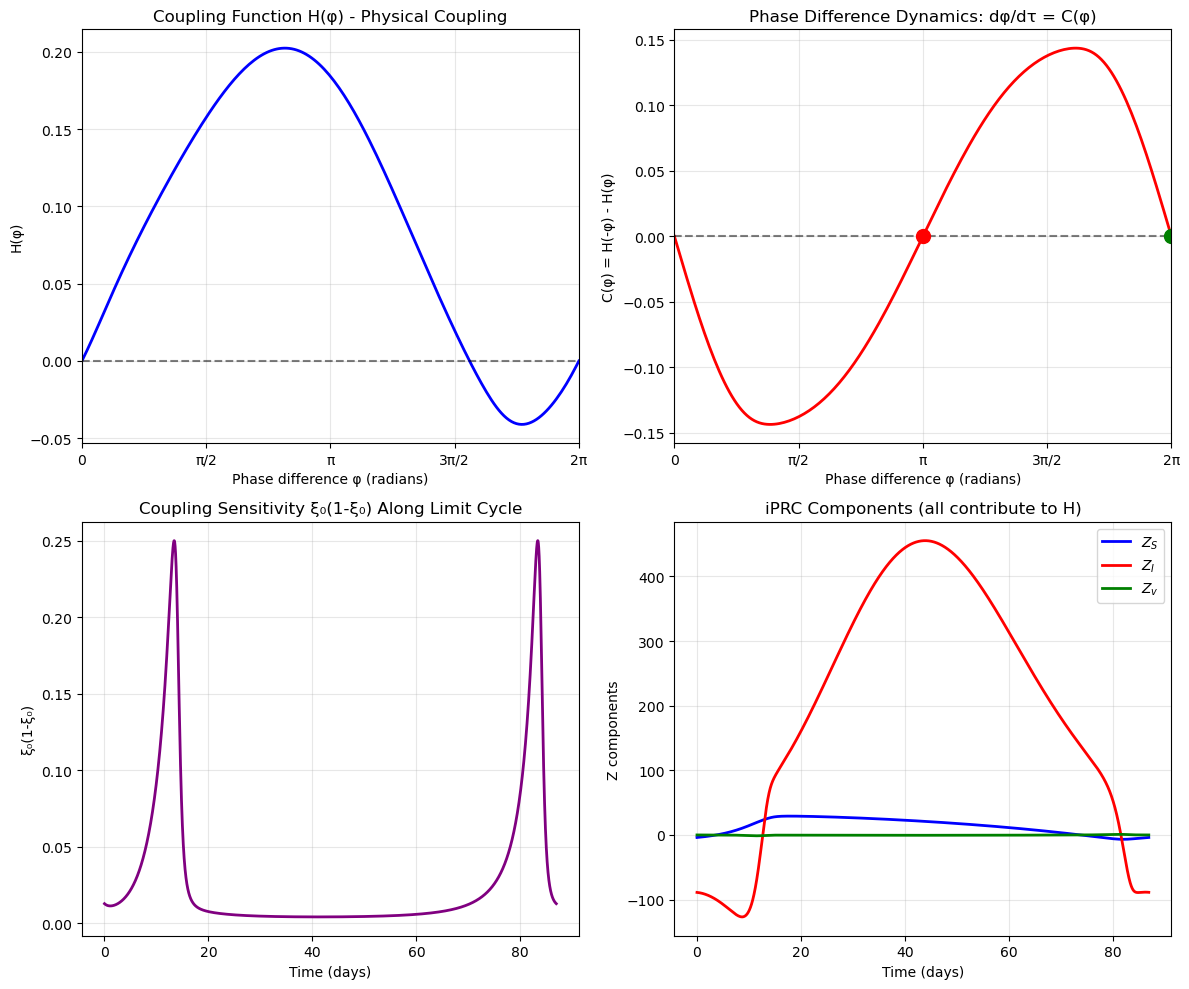


SUMMARY - PHYSICAL COUPLING MODEL
Period T = 86.9100 days
ω = 2π/T = 0.072295 rad/day

Coupling function H(φ) computed with Z·G = Z_S·G_S + Z_I·G_I + Z_v·G_v
Phase dynamics: dφ/dτ = H(-φ) - H(φ) = C(φ)

Phase-locked states occur where C(φ) = 0
  - Stable if C'(φ) < 0 (green dots)
  - Unstable if C'(φ) > 0 (red dots)


In [13]:
# =============================================================================
# COMPUTE THE COUPLING FUNCTION H(φ) - PHYSICAL COUPLING MODEL
# =============================================================================

# -----------------------------------------------------------------------------
# Step 1: Define helper functions for the coupling
# -----------------------------------------------------------------------------

def compute_xi0_along_cycle(Gamma, params):
    """
    Compute ξ₀(t) = 1/(1 + exp(-κ(βI(t)/ψ - ρ - θ(1-2v(t))))) along the limit cycle.
    Also returns ξ₀(1 - ξ₀) which appears in G_v.
    
    Returns:
        xi_0 : array of ξ₀(t) at each time point
        xi_0_deriv : array of ξ₀(t)(1 - ξ₀(t)) at each time point
    """
    kappa = params['kappa']
    beta = params['beta']
    psi = params['psi']
    rho = params['rho']
    theta = params['theta']
    
    # Argument of sigmoid
    q = beta * Gamma.I / psi - rho - theta * (1 - 2 * Gamma.v)
    
    # ξ₀(t)
    xi_0 = 1 / (1 + np.exp(-kappa * q))
    
    # ξ₀(1 - ξ₀) = σ'(q) (derivative of sigmoid)
    xi_0_deriv = xi_0 * (1 - xi_0)
    
    return xi_0, xi_0_deriv


xi_0, xi_0_deriv = compute_xi0_along_cycle(Gamma, params)

print("Computed ξ₀(t) and ξ₀(1-ξ₀) along the limit cycle")
print(f"  ξ₀ ranges from {xi_0.min():.6f} to {xi_0.max():.6f}")
print(f"  ξ₀(1-ξ₀) ranges from {xi_0_deriv.min():.6e} to {xi_0_deriv.max():.6e}")


# -----------------------------------------------------------------------------
# Step 2: Create interpolation functions for periodic extension
# -----------------------------------------------------------------------------

from scipy.interpolate import interp1d

def make_periodic_interp(t, y, T):
    """
    Create interpolation function with periodic extension.
    """
    t_one_period = t[:-1]
    y_one_period = y[:-1]
    
    t_extended = np.concatenate([t_one_period - T, t_one_period, t_one_period + T])
    y_extended = np.concatenate([y_one_period, y_one_period, y_one_period])
    
    interp_func = interp1d(t_extended, y_extended, kind='cubic')
    
    def periodic_func(t_query):
        t_mod = np.mod(t_query, T)
        return interp_func(t_mod)
    
    return periodic_func


# Create periodic interpolators for S and I (we need both for physical coupling)
S_interp = make_periodic_interp(Gamma.t, Gamma.S, Gamma.T)
I_interp = make_periodic_interp(Gamma.t, Gamma.I, Gamma.T)

print("Created periodic interpolations for S(t) and I(t)")


# -----------------------------------------------------------------------------
# Step 3: Compute H(φ) for a range of φ values
# -----------------------------------------------------------------------------

def compute_H(phi, Gamma, Z, xi_0_deriv, S_interp, I_interp, params):
    """
    Compute the coupling function H(φ) using numerical integration.
    
    H(φ) = (1/T) ∫₀ᵀ Z(t) · G(U(t), U(t+φ)) dt
    
    where for physical coupling:
        G_S = β·S(t)·(I(t)/ψ - I(t+φ)/(1-ψ))
        G_I = β·S(t)·(I(t+φ)/(1-ψ) - I(t)/ψ)
        G_v = κ·β·ξ₀(t)·(1-ξ₀(t))·(I(t+φ)/(1-ψ) - I(t)/ψ)
    
    Parameters:
        phi : float, phase difference
        Gamma : limit cycle container
        Z : adjoint solution container
        xi_0_deriv : array, ξ₀(t)(1-ξ₀(t)) along cycle
        S_interp, I_interp : functions, periodic interpolations
        params : dict, system parameters
    
    Returns:
        H : float, value of coupling function at φ
    """
    beta = params['beta']
    kappa = params['kappa']
    psi = params['psi']
    T = Gamma.T
    
    # Get I(t+φ) at each time point
    I_shifted = I_interp(Gamma.t + phi)
    
    # Common factor: (I(t+φ)/(1-ψ) - I(t)/ψ)
    infection_diff = I_shifted / (1 - psi) - Gamma.I / psi
    
    # Compute G components
    G_S = beta * Gamma.S * (-infection_diff)  # G_S = -β·S·(infection_diff)
    G_I = beta * Gamma.S * infection_diff      # G_I = β·S·(infection_diff)
    G_v = kappa * beta * xi_0_deriv * infection_diff  # G_v = κ·β·ξ₀(1-ξ₀)·(infection_diff)
    
    # The integrand: Z · G = Z_S·G_S + Z_I·G_I + Z_v·G_v
    integrand = Z.S * G_S + Z.I * G_I + Z.v * G_v
    
    # Numerical integration using trapezoidal rule
    H = np.trapz(integrand, Gamma.t) / T
    
    return H


# Compute H(φ) for φ ∈ [0, T]
n_phi = 200
phi_values = np.linspace(0, Gamma.T, n_phi)
H_values = np.zeros(n_phi)

for i, phi in enumerate(phi_values):
    H_values[i] = compute_H(phi, Gamma, Z, xi_0_deriv, S_interp, I_interp, params)

print(f"\nComputed H(φ) at {n_phi} points")
print(f"  H ranges from {H_values.min():.6e} to {H_values.max():.6e}")


# -----------------------------------------------------------------------------
# Step 4: Store H(φ) in a container
# -----------------------------------------------------------------------------

class H_function:
    """
    Container for the coupling function H(φ).
    """
    phi = phi_values
    theta = 2 * np.pi * phi_values / Gamma.T
    values = H_values
    T = Gamma.T

H = H_function()

H_interp = make_periodic_interp(H.phi, H.values, H.T)

print("\nH(φ) stored in H container")


# -----------------------------------------------------------------------------
# Step 5: Compute the odd part C(φ) = H(-φ) - H(φ)
# -----------------------------------------------------------------------------

C_values = np.zeros(n_phi)
for i, phi in enumerate(phi_values):
    H_minus_phi = compute_H(-phi, Gamma, Z, xi_0_deriv, S_interp, I_interp, params)
    C_values[i] = H_minus_phi - H_values[i]

print(f"\nComputed C(φ) = H(-φ) - H(φ)")
print(f"  C ranges from {C_values.min():.6e} to {C_values.max():.6e}")


# -----------------------------------------------------------------------------
# Step 6: Find fixed points (phase-locked states)
# -----------------------------------------------------------------------------

from scipy.interpolate import UnivariateSpline
from scipy.optimize import brentq

C_spline = UnivariateSpline(phi_values, C_values, s=0)
C_derivative = C_spline.derivative()

sign_changes = np.where(np.diff(np.sign(C_values)))[0]

print("\n" + "="*50)
print("PHASE-LOCKED STATES - PHYSICAL COUPLING MODEL")
print("="*50)

for idx in sign_changes:
    phi_left = phi_values[idx]
    phi_right = phi_values[idx + 1]
    
    try:
        phi_zero = brentq(C_spline, phi_left, phi_right)
        C_prime_at_zero = C_derivative(phi_zero)
        stability = "STABLE" if C_prime_at_zero < 0 else "UNSTABLE"
        
        theta_zero = 2 * np.pi * phi_zero / Gamma.T
        
        print(f"\n  φ = {phi_zero:.4f} days (θ = {theta_zero:.4f} rad = {np.degrees(theta_zero):.1f}°)")
        print(f"    C'(φ) = {C_prime_at_zero:.6e}")
        print(f"    {stability}")
    except:
        pass


# -----------------------------------------------------------------------------
# Step 7: Plot everything
# -----------------------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot H(φ)
ax1 = axes[0, 0]
ax1.plot(H.theta, H.values, 'b-', linewidth=2)
ax1.axhline(y=0, color='k', linestyle='--', alpha=0.5)
ax1.set_xlabel('Phase difference φ (radians)')
ax1.set_ylabel('H(φ)')
ax1.set_title('Coupling Function H(φ) - Physical Coupling')
ax1.set_xlim([0, 2*np.pi])
ax1.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax1.set_xticklabels(['0', 'π/2', 'π', '3π/2', '2π'])
ax1.grid(True, alpha=0.3)

# Plot C(φ)
ax2 = axes[0, 1]
theta_values = 2 * np.pi * phi_values / Gamma.T
ax2.plot(theta_values, C_values, 'r-', linewidth=2)
ax2.axhline(y=0, color='k', linestyle='--', alpha=0.5)
ax2.set_xlabel('Phase difference φ (radians)')
ax2.set_ylabel('C(φ) = H(-φ) - H(φ)')
ax2.set_title('Phase Difference Dynamics: dφ/dτ = C(φ)')
ax2.set_xlim([0, 2*np.pi])
ax2.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax2.set_xticklabels(['0', 'π/2', 'π', '3π/2', '2π'])
ax2.grid(True, alpha=0.3)

# Mark fixed points
for idx in sign_changes:
    try:
        phi_left = phi_values[idx]
        phi_right = phi_values[idx + 1]
        phi_zero = brentq(C_spline, phi_left, phi_right)
        theta_zero = 2 * np.pi * phi_zero / Gamma.T
        C_prime = C_derivative(phi_zero)
        color = 'go' if C_prime < 0 else 'ro'
        ax2.plot(theta_zero, 0, color, markersize=10)
    except:
        pass

# Plot ξ₀(1-ξ₀) to show coupling sensitivity
ax3 = axes[1, 0]
ax3.plot(Gamma.t, xi_0_deriv, 'purple', linewidth=2)
ax3.set_xlabel('Time (days)')
ax3.set_ylabel("ξ₀(1-ξ₀)")
ax3.set_title("Coupling Sensitivity ξ₀(1-ξ₀) Along Limit Cycle")
ax3.grid(True, alpha=0.3)

# Plot all Z components
ax4 = axes[1, 1]
ax4.plot(Z.t, Z.S, 'b-', linewidth=2, label='$Z_S$')
ax4.plot(Z.t, Z.I, 'r-', linewidth=2, label='$Z_I$')
ax4.plot(Z.t, Z.v, 'g-', linewidth=2, label='$Z_v$')
ax4.set_xlabel('Time (days)')
ax4.set_ylabel('Z components')
ax4.set_title('iPRC Components (all contribute to H)')
ax4.grid(True, alpha=0.3)
ax4.legend()

plt.tight_layout()
plt.savefig('coupling_function_H_physical.png', dpi=150)
plt.show()

print("\n" + "="*50)
print("SUMMARY - PHYSICAL COUPLING MODEL")
print("="*50)
print(f"Period T = {Gamma.T:.4f} days")
print(f"ω = 2π/T = {2*np.pi/Gamma.T:.6f} rad/day")
print(f"\nCoupling function H(φ) computed with Z·G = Z_S·G_S + Z_I·G_I + Z_v·G_v")
print(f"Phase dynamics: dφ/dτ = H(-φ) - H(φ) = C(φ)")
print(f"\nPhase-locked states occur where C(φ) = 0")
print(f"  - Stable if C'(φ) < 0 (green dots)")
print(f"  - Unstable if C'(φ) > 0 (red dots)")

## So the anti-phase is no longer stable then. Let's simulate and see if it's true.

Testing ANTI-PHASE stability (φ = π) - PHYSICAL COUPLING MODEL
Oscillator 1 starts at: S=0.1428, I=0.0156, v=0.9446
Oscillator 2 starts at: S=0.1502, I=0.0016, v=0.0041


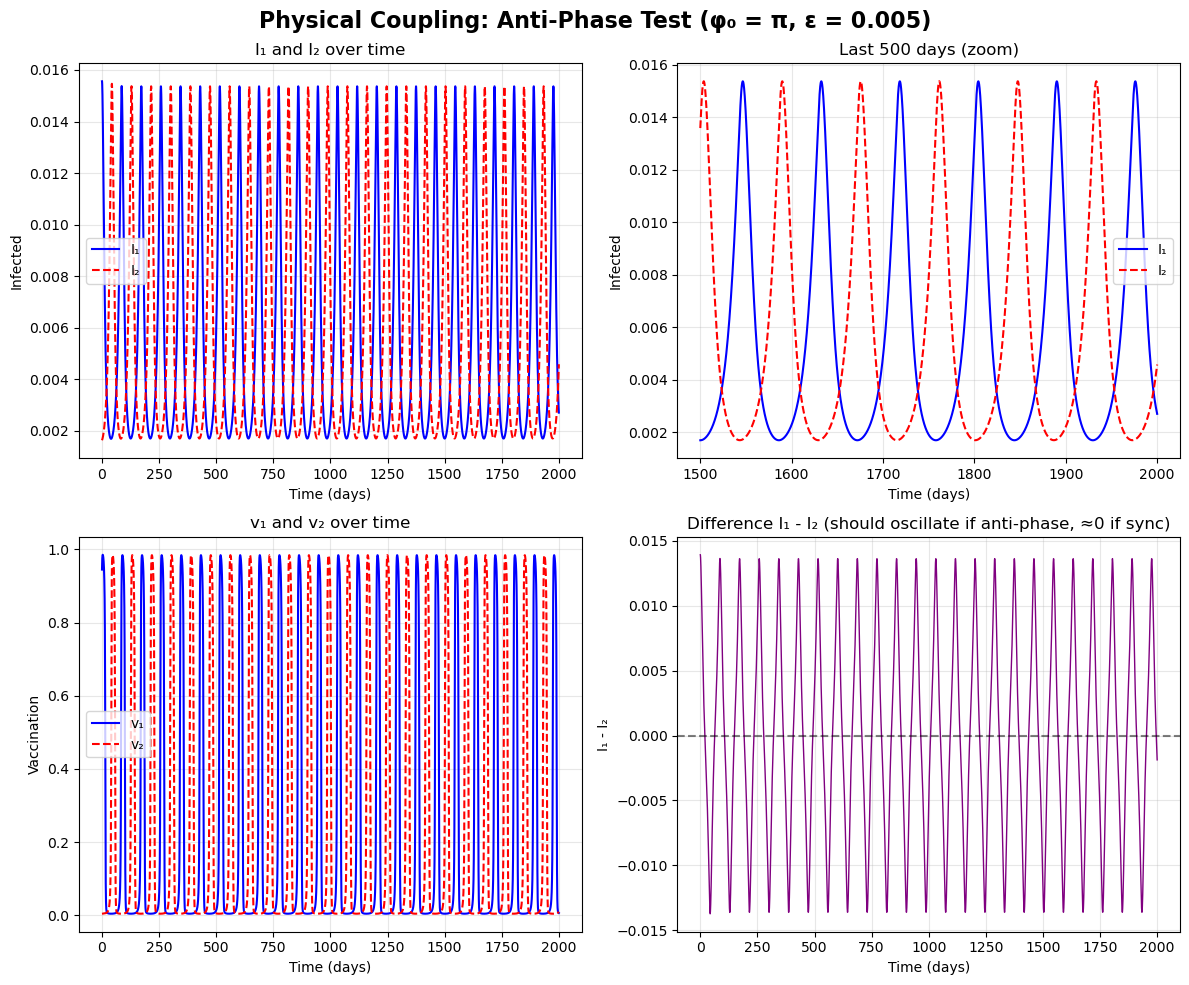


DIAGNOSIS - PHYSICAL COUPLING MODEL

In the final segment:
  Mean |I₁ - I₂| = 0.006669
  Std(I₁ - I₂) = 0.007938

→ ANTI-PHASE (I₁ - I₂ oscillates)
  This confirms: anti-phase (φ = π) is STABLE


In [62]:
# =============================================================================
# TEST SYNCHRONIZATION/ANTI-PHASE STABILITY - PHYSICAL COUPLING MODEL, epsilon = 0.005
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Define the coupled system - PHYSICAL COUPLING
def coupled_sirv_physical(t, y, alpha, beta, gamma, epsilon, eta, theta, kappa, rho, psi):
    S1, I1, v1, S2, I2, v2 = y
    
    # Effective infection rates seen by each group
    infection_rate_1 = (1 - epsilon) * I1 / psi + epsilon * I2 / (1 - psi)
    infection_rate_2 = (1 - epsilon) * I2 / (1 - psi) + epsilon * I1 / psi
    
    # Group 1 dynamics
    dS1 = alpha*(psi - S1 - I1) - beta*S1*infection_rate_1 - eta*v1*S1
    dI1 = -gamma*I1 + beta*S1*infection_rate_1
    dv1 = -v1 + 1/(1 + np.exp(-kappa*(beta*infection_rate_1 - rho - theta*(1 - 2*v1))))
    
    # Group 2 dynamics
    dS2 = alpha*(1 - psi - S2 - I2) - beta*S2*infection_rate_2 - eta*v2*S2
    dI2 = -gamma*I2 + beta*S2*infection_rate_2
    dv2 = -v2 + 1/(1 + np.exp(-kappa*(beta*infection_rate_2 - rho - theta*(1 - 2*v2))))
    
    return [dS1, dI1, dv1, dS2, dI2, dv2]

# Parameters
params = {
    'alpha': 0.01,
    'beta': 0.5,
    'gamma': 1/7,
    'epsilon': 0.005,
    'eta': 1/7,
    'theta': 0.01,
    'kappa': 300,
    'rho': 0.01,
    'psi': 0.5
}

# -----------------------------------------------------------------------------
# Set up initial conditions at ANTI-PHASE (φ = π)
# -----------------------------------------------------------------------------

phi_0_radians = np.pi  # anti-phase
phi_0_time = phi_0_radians * Gamma.T / (2 * np.pi)  # convert to time units

# Oscillator 1: starts at phase 0
S1_0 = Gamma.S[0]
I1_0 = Gamma.I[0]
v1_0 = Gamma.v[0]

# Oscillator 2: starts at phase π (half period ahead)
S2_0 = np.interp(phi_0_time % Gamma.T, Gamma.t, Gamma.S)
I2_0 = np.interp(phi_0_time % Gamma.T, Gamma.t, Gamma.I)
v2_0 = np.interp(phi_0_time % Gamma.T, Gamma.t, Gamma.v)

y0_antiphase = [S1_0, I1_0, v1_0, S2_0, I2_0, v2_0]

print(f"Testing ANTI-PHASE stability (φ = π) - PHYSICAL COUPLING MODEL")
print(f"Oscillator 1 starts at: S={S1_0:.4f}, I={I1_0:.4f}, v={v1_0:.4f}")
print(f"Oscillator 2 starts at: S={S2_0:.4f}, I={I2_0:.4f}, v={v2_0:.4f}")

# -----------------------------------------------------------------------------
# Simulate
# -----------------------------------------------------------------------------

t_span = (0, 2000)
t_eval = np.linspace(t_span[0], t_span[1], 20000)

sol = solve_ivp(
    coupled_sirv_physical,
    t_span,
    y0_antiphase,
    args=(params['alpha'], params['beta'], params['gamma'], params['epsilon'],
          params['eta'], params['theta'], params['kappa'], params['rho'], params['psi']),
    t_eval=t_eval,
    method='LSODA',
    rtol=1e-8,
    atol=1e-10
)

S1, I1, v1, S2, I2, v2 = sol.y

# -----------------------------------------------------------------------------
# Plot results
# -----------------------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(f'Physical Coupling: Anti-Phase Test (φ₀ = π, ε = {params["epsilon"]})', fontsize=16, fontweight='bold')

# I1 vs I2
ax1 = axes[0, 0]
ax1.plot(sol.t, I1, 'b-', label='I₁', linewidth=1.5)
ax1.plot(sol.t, I2, 'r--', label='I₂', linewidth=1.5)
ax1.set_xlabel('Time (days)')
ax1.set_ylabel('Infected')
ax1.set_title('I₁ and I₂ over time')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Zoom on last 500 days
ax2 = axes[0, 1]
t_zoom = sol.t > sol.t[-1] - 500
ax2.plot(sol.t[t_zoom], I1[t_zoom], 'b-', label='I₁', linewidth=1.5)
ax2.plot(sol.t[t_zoom], I2[t_zoom], 'r--', label='I₂', linewidth=1.5)
ax2.set_xlabel('Time (days)')
ax2.set_ylabel('Infected')
ax2.set_title('Last 500 days (zoom)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# v1 vs v2
ax3 = axes[1, 0]
ax3.plot(sol.t, v1, 'b-', label='v₁', linewidth=1.5)
ax3.plot(sol.t, v2, 'r--', label='v₂', linewidth=1.5)
ax3.set_xlabel('Time (days)')
ax3.set_ylabel('Vaccination')
ax3.set_title('v₁ and v₂ over time')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Check: are they in sync or anti-phase?
ax4 = axes[1, 1]
ax4.plot(sol.t, I1 - I2, 'purple', linewidth=1)
ax4.axhline(y=0, color='k', linestyle='--', alpha=0.5)
ax4.set_xlabel('Time (days)')
ax4.set_ylabel('I₁ - I₂')
ax4.set_title('Difference I₁ - I₂ (should oscillate if anti-phase, ≈0 if sync)')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# Diagnose
# -----------------------------------------------------------------------------

print("\n" + "="*50)
print("DIAGNOSIS - PHYSICAL COUPLING MODEL")
print("="*50)

final_segment = -2000  # last 2000 time points
I_diff = I1[final_segment:] - I2[final_segment:]
mean_abs_diff = np.mean(np.abs(I_diff))
std_diff = np.std(I_diff)

print(f"\nIn the final segment:")
print(f"  Mean |I₁ - I₂| = {mean_abs_diff:.6f}")
print(f"  Std(I₁ - I₂) = {std_diff:.6f}")

if mean_abs_diff < 0.001:
    print("\n→ SYNCHRONIZED (I₁ ≈ I₂)")
    print("  This confirms: synchrony (φ = 0) is STABLE")
elif std_diff > 0.001:
    print("\n→ ANTI-PHASE (I₁ - I₂ oscillates)")
    print("  This confirms: anti-phase (φ = π) is STABLE")
else:
    print("\n→ Some other phase-locked state")

## It looks like anti-phase locked cos $\epsilon = 0.005$ is too small and makes the system hit convergence very slowly

Testing with ε = 0.005
Expected time scale for phase dynamics: ~1/ε = 200 periods
One period T = 86.9 days
So convergence may take ~17382 days


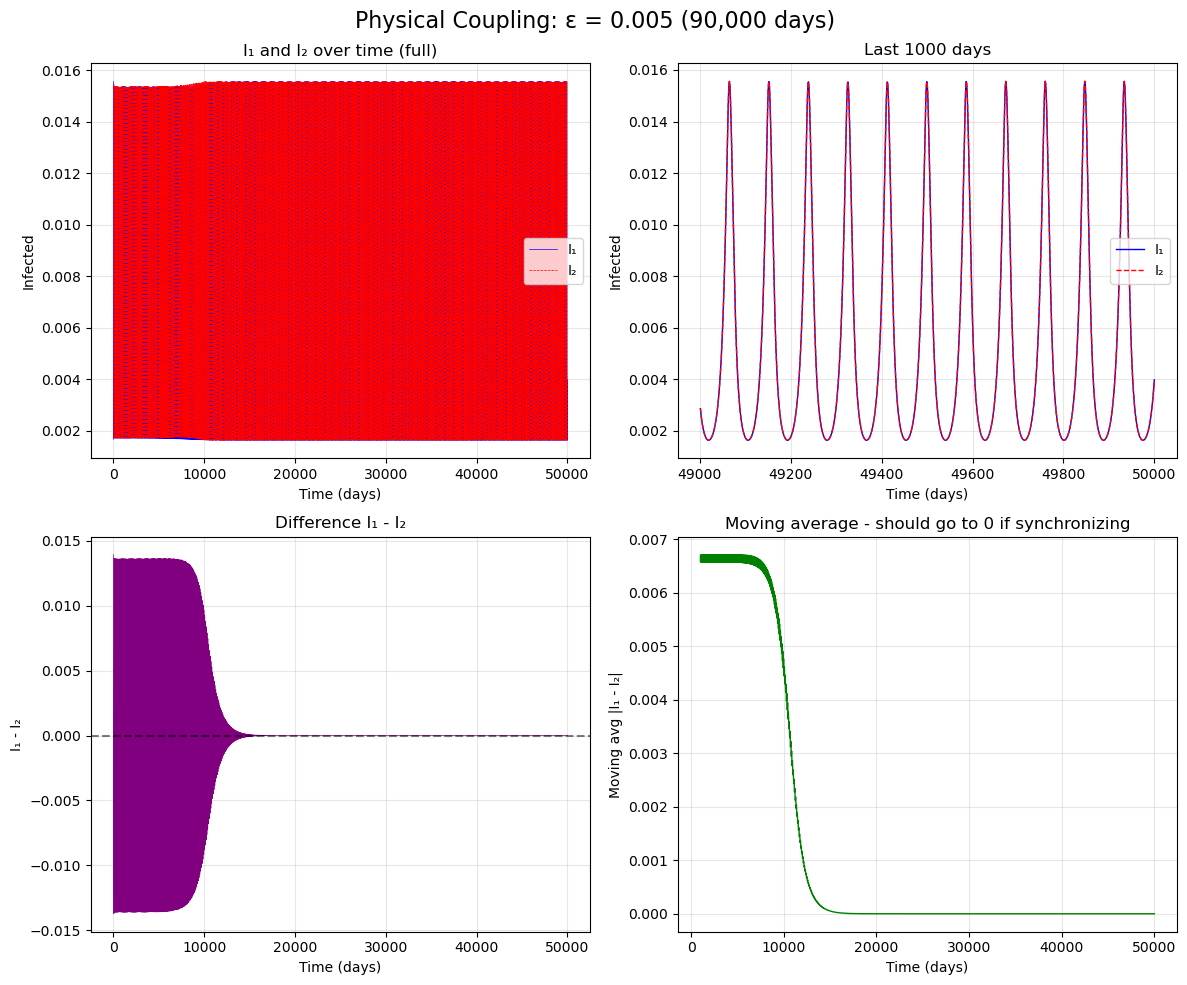


DIAGNOSIS

Mean |I₁ - I₂| (early, t~5000-10000): 0.006001
Mean |I₁ - I₂| (final, last 5000 pts): 0.000000

→ SYNCHRONIZED! Theory confirmed ✓


In [78]:
# =============================================================================
# TEST WITH EPSILON = 0.005, SIMULATE TO 90000 DAYS
# =============================================================================

params_test = params.copy()
params_test['epsilon'] = 0.005

print(f"Testing with ε = {params_test['epsilon']}")
print(f"Expected time scale for phase dynamics: ~1/ε = {1/params_test['epsilon']:.0f} periods")
print(f"One period T = {Gamma.T:.1f} days")
print(f"So convergence may take ~{Gamma.T / params_test['epsilon']:.0f} days")

# Simulate
t_span_long = (0, 50000)
t_eval_long = np.linspace(t_span_long[0], t_span_long[1], 50000)

sol_long = solve_ivp(
    coupled_sirv_physical,
    t_span_long,
    y0_antiphase,
    args=(params_test['alpha'], params_test['beta'], params_test['gamma'], 
          params_test['epsilon'], params_test['eta'], params_test['theta'], 
          params_test['kappa'], params_test['rho'], params_test['psi']),
    t_eval=t_eval_long,
    method='LSODA',
    rtol=1e-8,
    atol=1e-10
)

S1, I1, v1, S2, I2, v2 = sol_long.y

# Plot
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(f'Physical Coupling: ε = {params_test["epsilon"]} (90,000 days)', fontsize=16)

ax1 = axes[0, 0]
ax1.plot(sol_long.t, I1, 'b-', label='I₁', linewidth=0.5)
ax1.plot(sol_long.t, I2, 'r--', label='I₂', linewidth=0.5)
ax1.set_xlabel('Time (days)')
ax1.set_ylabel('Infected')
ax1.set_title('I₁ and I₂ over time (full)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[0, 1]
t_zoom = sol_long.t > sol_long.t[-1] - 1000
ax2.plot(sol_long.t[t_zoom], I1[t_zoom], 'b-', label='I₁', linewidth=1)
ax2.plot(sol_long.t[t_zoom], I2[t_zoom], 'r--', label='I₂', linewidth=1)
ax2.set_xlabel('Time (days)')
ax2.set_ylabel('Infected')
ax2.set_title('Last 1000 days')
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3 = axes[1, 0]
ax3.plot(sol_long.t, I1 - I2, 'purple', linewidth=0.5)
ax3.axhline(y=0, color='k', linestyle='--', alpha=0.5)
ax3.set_xlabel('Time (days)')
ax3.set_ylabel('I₁ - I₂')
ax3.set_title('Difference I₁ - I₂')
ax3.grid(True, alpha=0.3)

window = 1000
I_diff_abs = np.abs(I1 - I2)
I_diff_ma = np.convolve(I_diff_abs, np.ones(window)/window, mode='valid')
ax4 = axes[1, 1]
ax4.plot(sol_long.t[window-1:], I_diff_ma, 'green', linewidth=1)
ax4.set_xlabel('Time (days)')
ax4.set_ylabel('Moving avg |I₁ - I₂|')
ax4.set_title(f'Moving average - should go to 0 if synchronizing')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Diagnosis
print("\n" + "="*50)
print("DIAGNOSIS")
print("="*50)
final_diff = np.mean(np.abs(I1[-5000:] - I2[-5000:]))
early_diff = np.mean(np.abs(I1[5000:10000] - I2[5000:10000]))
print(f"\nMean |I₁ - I₂| (early, t~5000-10000): {early_diff:.6f}")
print(f"Mean |I₁ - I₂| (final, last 5000 pts): {final_diff:.6f}")

if final_diff < 0.001:
    print("\n→ SYNCHRONIZED! Theory confirmed ✓")
elif final_diff < early_diff * 0.5:
    print("\n→ Converging to SYNCHRONY (not quite there yet)")
else:
    print("\n→ Still converging slowly...")

Testing with ε = 0.01
Expected convergence time: ~8691 days


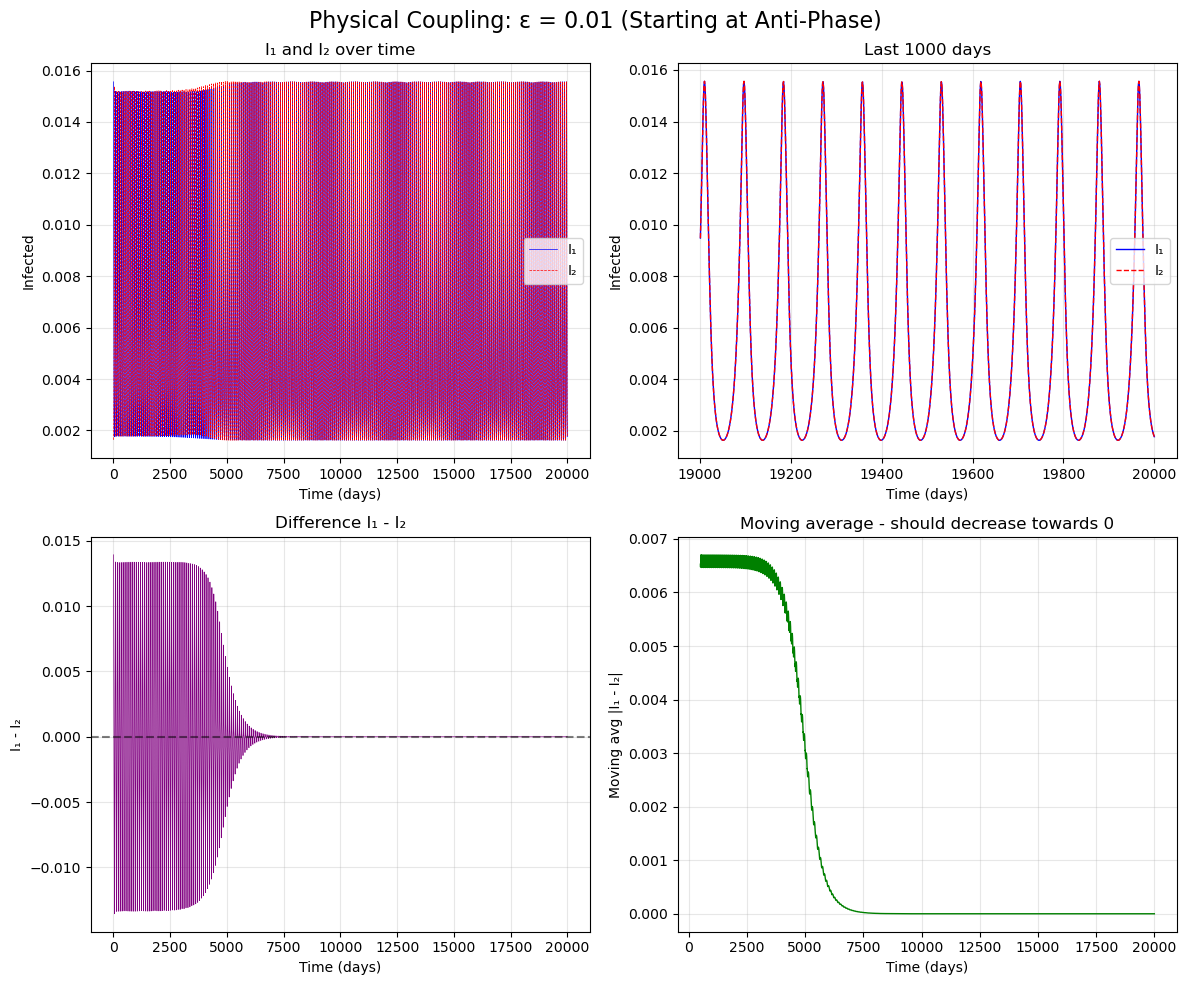


DIAGNOSIS
Mean |I₁ - I₂| in last 2000 points: 0.000000
→ SYNCHRONIZED! Theory confirmed.


In [70]:
# =============================================================================
# TEST WITH INTERMEDIATE EPSILON = 0.01
# =============================================================================

params_mid_eps = params.copy()
params_mid_eps['epsilon'] = 0.01

print(f"Testing with ε = {params_mid_eps['epsilon']}")
print(f"Expected convergence time: ~{Gamma.T / params_mid_eps['epsilon']:.0f} days")

# Simulate
t_span = (0, 20000)
t_eval = np.linspace(t_span[0], t_span[1], 20000)

sol = solve_ivp(
    coupled_sirv_physical,
    t_span,
    y0_antiphase,  # Start at anti-phase
    args=(params_mid_eps['alpha'], params_mid_eps['beta'], params_mid_eps['gamma'], 
          params_mid_eps['epsilon'], params_mid_eps['eta'], params_mid_eps['theta'], 
          params_mid_eps['kappa'], params_mid_eps['rho'], params_mid_eps['psi']),
    t_eval=t_eval,
    method='LSODA',
    rtol=1e-8,
    atol=1e-10
)

S1, I1, v1, S2, I2, v2 = sol.y

# Plot
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(f'Physical Coupling: ε = {params_mid_eps["epsilon"]} (Starting at Anti-Phase)', fontsize=16)

ax1 = axes[0, 0]
ax1.plot(sol.t, I1, 'b-', label='I₁', linewidth=0.5)
ax1.plot(sol.t, I2, 'r--', label='I₂', linewidth=0.5)
ax1.set_xlabel('Time (days)')
ax1.set_ylabel('Infected')
ax1.set_title('I₁ and I₂ over time')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[0, 1]
t_zoom = sol.t > sol.t[-1] - 1000
ax2.plot(sol.t[t_zoom], I1[t_zoom], 'b-', label='I₁', linewidth=1)
ax2.plot(sol.t[t_zoom], I2[t_zoom], 'r--', label='I₂', linewidth=1)
ax2.set_xlabel('Time (days)')
ax2.set_ylabel('Infected')
ax2.set_title('Last 1000 days')
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3 = axes[1, 0]
ax3.plot(sol.t, I1 - I2, 'purple', linewidth=0.5)
ax3.axhline(y=0, color='k', linestyle='--', alpha=0.5)
ax3.set_xlabel('Time (days)')
ax3.set_ylabel('I₁ - I₂')
ax3.set_title('Difference I₁ - I₂')
ax3.grid(True, alpha=0.3)

# Moving average
window = 500
I_diff_abs = np.abs(I1 - I2)
I_diff_ma = np.convolve(I_diff_abs, np.ones(window)/window, mode='valid')
ax4 = axes[1, 1]
ax4.plot(sol.t[window-1:], I_diff_ma, 'green', linewidth=1)
ax4.set_xlabel('Time (days)')
ax4.set_ylabel('Moving avg |I₁ - I₂|')
ax4.set_title(f'Moving average - should decrease towards 0')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Final diagnosis
print("\n" + "="*50)
print("DIAGNOSIS")
print("="*50)
final_diff = np.mean(np.abs(I1[-2000:] - I2[-2000:]))
print(f"Mean |I₁ - I₂| in last 2000 points: {final_diff:.6f}")

if final_diff < 0.001:
    print("→ SYNCHRONIZED! Theory confirmed.")
else:
    print(f"→ Still converging... (expected time ~{Gamma.T / params_mid_eps['epsilon']:.0f} days)")